# مدل CNN–BiLSTM با توجه افزایشی زمانی برای پیش‌بینی RUL

این نوت‌بوک نسخه پیشنهادی فصل سوم است. برای حفظ مقایسه منصفانه با مدل فصل دوم، تمام تنظیمات اصلی ثابت نگه داشته شده‌اند و فقط لایه `Flatten` با **Temporal Additive Attention** جایگزین شده است.

مسیر مدل:

`Input → Conv1D → Dropout → BiLSTM → Dropout → Temporal Additive Attention → Dense`

نکات اجرا:

1. ابتدا سلول‌ها را در حالت `pilot` اجرا کنید؛ این حالت فقط Seed شماره 11 را اجرا می‌کند و نتیجه آن نهایی نیست.
2. پس از اجرای موفق، در سلول تنظیمات مقدار `RUN_MODE` را از `"pilot"` به `"final"` تغییر دهید و Runtime را از ابتدا اجرا کنید.
3. حالت `final` مدل را با همان ۱۰ Seed فصل دوم اجرا می‌کند.
4. سه فایل `train_FD001.txt`، `test_FD001.txt` و `RUL_FD001.txt` باید در مسیر `/content` قرار گیرند.
5. تمام خروجی‌های عددی و نمودارها در یک فایل ZIP ذخیره می‌شوند.

اجرای آزمایشی نباید در پایان‌نامه گزارش شود.

In [1]:
# سلول 1: کتابخانه‌ها، تنظیم بذر و مسیر خروجی
import os
import time
import random
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from scipy import interpolate
from sklearn import preprocessing
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input, Conv1D, Dropout, LSTM, Bidirectional, Dense,
    Softmax, Multiply, Lambda
)
from tensorflow.keras.optimizers import Adam

OUTPUT_DIR = Path('/content/FD001_CNN_BiLSTM_Attention_results')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('TensorFlow version:', tf.__version__)
print('Output directory:', OUTPUT_DIR)

TensorFlow version: 2.20.0
Output directory: /content/FD001_CNN_BiLSTM_Attention_results


In [2]:
# سلول 2: بارگذاری فایل‌های FD001 در Google Colab
from google.colab import files

required_files = [
    '/content/train_FD001.txt',
    '/content/test_FD001.txt',
    '/content/RUL_FD001.txt'
]

missing_files = [p for p in required_files if not os.path.exists(p)]

if missing_files:
    print('سه فایل FD001 را انتخاب و بارگذاری کنید:')
    uploaded = files.upload()

missing_files = [p for p in required_files if not os.path.exists(p)]
if missing_files:
    raise FileNotFoundError(f'فایل‌های زیر پیدا نشدند: {missing_files}')

print('هر سه فایل داده آماده‌اند.')

سه فایل FD001 را انتخاب و بارگذاری کنید:


Saving RUL_FD001.txt to RUL_FD001.txt
Saving test_FD001.txt to test_FD001.txt
Saving train_FD001.txt to train_FD001.txt
هر سه فایل داده آماده‌اند.


In [3]:
# سلول 3: تنظیمات ثابت آزمایش
# برای اجرای آزمایشی: pilot
# برای 10 اجرای نهایی: final
RUN_MODE = 'final'

ALL_SEEDS = [11, 22, 33, 44, 55, 66, 77, 88, 99, 110]
SEEDS = ALL_SEEDS[:1] if RUN_MODE == 'pilot' else ALL_SEEDS

MAX_RUL = 125.0
WINDOW_SIZE = 25
INPUT_DIMS = 14

CNN_FILTERS = 64
KERNEL_SIZE = 3
BILSTM_UNITS = 64
ATTENTION_UNITS = 64
DROPOUT_RATE = 0.3

LEARNING_RATE = 0.001
BATCH_SIZE = 256
EPOCHS = 64

print('Run mode:', RUN_MODE)
print('Number of runs:', len(SEEDS))
print('Seeds:', SEEDS)

if RUN_MODE == 'pilot':
    print('\nهشدار: این اجرای آزمایشی است و نتیجه آن نباید در پایان‌نامه گزارش شود.')

Run mode: final
Number of runs: 10
Seeds: [11, 22, 33, 44, 55, 66, 77, 88, 99, 110]


In [4]:
# سلول 4: پیش‌پردازش دقیقاً مطابق مدل پایه فصل دوم
scaler = preprocessing.MinMaxScaler()

rul_raw = np.loadtxt('/content/RUL_FD001.txt')
train_raw = np.loadtxt('/content/train_FD001.txt')
test_raw = np.loadtxt('/content/test_FD001.txt')

# نرمال‌سازی با برازش فقط روی داده آموزش
train_raw[:, 2:] = scaler.fit_transform(train_raw[:, 2:])
test_raw[:, 2:] = scaler.transform(test_raw[:, 2:])

# حذف سه متغیر شرایط عملیاتی و هفت حسگر ثابت/کم‌اطلاعات
columns_to_delete = [2, 3, 4, 5, 9, 10, 14, 20, 22, 23]
train_nor = np.delete(train_raw, columns_to_delete, axis=1)
test_nor = np.delete(test_raw, columns_to_delete, axis=1)

train_x, train_y = [], []

for engine_id in range(1, int(np.max(train_nor[:, 0])) + 1):
    indices = np.where(train_nor[:, 0] == engine_id)[0]
    engine_data = train_nor[indices, :]

    for start in range(len(engine_data) - WINDOW_SIZE + 1):
        train_x.append(engine_data[start:start + WINDOW_SIZE, 2:])
        current_rul = len(engine_data) - WINDOW_SIZE - start
        train_y.append(min(current_rul, MAX_RUL))

test_x, test_y = [], []

for engine_id in range(1, int(np.max(test_nor[:, 0])) + 1):
    indices = np.where(test_nor[:, 0] == engine_id)[0]
    engine_data = test_nor[indices, :]

    if len(engine_data) < WINDOW_SIZE:
        interpolated_columns = []
        for column_index in range(engine_data.shape[1]):
            x_old = np.linspace(0, WINDOW_SIZE - 1, len(engine_data))
            x_new = np.linspace(0, WINDOW_SIZE - 1, WINDOW_SIZE)
            spline = interpolate.splrep(x_old, engine_data[:, column_index])
            interpolated_columns.append(interpolate.splev(x_new, spline))
        engine_window = np.asarray(interpolated_columns).T[:, 2:]
    else:
        engine_window = engine_data[-WINDOW_SIZE:, 2:]

    test_x.append(engine_window)
    test_y.append(min(float(rul_raw[engine_id - 1]), MAX_RUL))

trainData = np.asarray(train_x, dtype=np.float32)
trainTarget = np.asarray(train_y, dtype=np.float32) / MAX_RUL
testData = np.asarray(test_x, dtype=np.float32)
testTarget = np.asarray(test_y, dtype=np.float32)

assert trainData.shape[1:] == (WINDOW_SIZE, INPUT_DIMS)
assert testData.shape[1:] == (WINDOW_SIZE, INPUT_DIMS)

print('Train input shape:', trainData.shape)
print('Train target shape:', trainTarget.shape)
print('Test input shape:', testData.shape)
print('Test target shape:', testTarget.shape)

Train input shape: (18231, 25, 14)
Train target shape: (18231,)
Test input shape: (100, 25, 14)
Test target shape: (100,)


## تعریف توجه افزایشی زمانی

خروجی BiLSTM برای هر نمونه دارای ابعاد $25\times128$ است. سازوکار توجه برای هر یک از ۲۵ گام زمانی امتیاز می‌سازد:

$$u_t=\tanh(W_a h_t+b_a)$$

$$e_t=v_a^T u_t$$

$$\alpha_t=\frac{\exp(e_t)}{\sum_j\exp(e_j)}$$

$$c=\sum_t\alpha_t h_t$$

بردار زمینه $c$ دارای ۱۲۸ مؤلفه است و برای پیش‌بینی RUL به لایه خروجی منتقل می‌شود.

In [5]:
# سلول 5: ساخت مدل CNN–BiLSTM–Temporal Additive Attention
def build_attention_model():
    inputs = Input(shape=(WINDOW_SIZE, INPUT_DIMS), name='sensor_window')

    x = Conv1D(
        filters=CNN_FILTERS,
        kernel_size=KERNEL_SIZE,
        activation='relu',
        padding='same',
        name='conv1d_features'
    )(inputs)
    x = Dropout(DROPOUT_RATE, name='dropout_after_cnn')(x)

    h = Bidirectional(
        LSTM(BILSTM_UNITS, return_sequences=True),
        merge_mode='concat',
        name='bidirectional_lstm'
    )(x)
    h = Dropout(DROPOUT_RATE, name='dropout_after_bilstm')(h)

    # u_t = tanh(W_a h_t + b_a)
    attention_hidden = Dense(
        ATTENTION_UNITS,
        activation='tanh',
        name='attention_hidden'
    )(h)

    # e_t = v_a^T u_t
    attention_scores = Dense(
        1,
        use_bias=False,
        name='attention_score'
    )(attention_hidden)

    # alpha_t: نرمال‌سازی روی محور زمان
    attention_weights = Softmax(
        axis=1,
        name='attention_weights'
    )(attention_scores)

    weighted_sequence = Multiply(name='weighted_bilstm_outputs')(
        [h, attention_weights]
    )

    context_vector = Lambda(
        lambda tensor: tf.reduce_sum(tensor, axis=1),
        name='context_vector'
    )(weighted_sequence)

    output = Dense(1, activation='linear', name='rul_output')(context_vector)

    model = Model(inputs=inputs, outputs=output, name='CNN_BiLSTM_Temporal_Additive_Attention')
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='mse'
    )
    return model


tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEEDS[0])
preview_model = build_attention_model()
preview_model.summary()

expected_attention_shape = (None, WINDOW_SIZE, 1)
actual_attention_shape = tuple(preview_model.get_layer('attention_weights').output.shape)
assert actual_attention_shape == expected_attention_shape, (
    f'Attention shape mismatch: {actual_attention_shape}'
)
print('\nAttention output shape:', actual_attention_shape)

Model: "CNN_BiLSTM_Temporal_Additive_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sensor_window       │ (None, 25, 14)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_features     │ (None, 25, 64)    │      2,752 │ sensor_window[0]… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_after_cnn   │ (None, 25, 64)    │          0 │ conv1d_features[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_lstm  │ (None, 25, 128)   │     66,048 │ dropout_after_cn… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_after_bils… │ (None, 25, 128)   │          0 │ bidirectional_ls… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_hidden    │ (None, 25, 64)    │      8,256 │ dropout_after_bi… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_score     │ (None, 25, 1)     │         64 │ attention_hidden… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_weights   │ (None, 25, 1)     │          0 │ attention_score[… │
│ (Softmax)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ weighted_bilstm_ou… │ (None, 25, 128)   │          0 │ dropout_after_bi… │
│ (Multiply)          │                   │            │ attention_weight… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ context_vector      │ (None, 128)       │          0 │ weighted_bilstm_… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rul_output (Dense)  │ (None, 1)         │        129 │ context_vector[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 77,249 (301.75 KB)

 Trainable params: 77,249 (301.75 KB)

 Non-trainable params: 0 (0.00 B)


Attention output shape: (None, 25, 1)


In [6]:
# سلول 6: توابع معیار و تنظیم بذر
def set_seed(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)
    try:
        tf.config.experimental.enable_op_determinism()
    except Exception:
        pass


def nasa_score(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float).reshape(-1)
    y_pred = np.asarray(y_pred, dtype=float).reshape(-1)
    error = y_pred - y_true
    penalties = np.where(
        error >= 0,
        np.exp(error / 10.0) - 1.0,
        np.exp(-error / 13.0) - 1.0
    )
    return float(np.sum(penalties))

In [7]:
# سلول 7: آموزش مستقل مدل و استخراج پیش‌بینی‌ها و وزن‌های Attention
run_metrics = []
run_predictions = []
run_attention_weights = []
run_loss_histories = []

total_start = time.perf_counter()

for run_number, seed in enumerate(SEEDS, start=1):
    print(f'\n========== Run {run_number}/{len(SEEDS)} | Seed {seed} ==========')

    tf.keras.backend.clear_session()
    set_seed(seed)

    model = build_attention_model()
    start_time = time.perf_counter()

    history = model.fit(
        trainData,
        trainTarget,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        shuffle=True,
        verbose=1
    )

    elapsed_seconds = time.perf_counter() - start_time

    predictions = model.predict(
        testData,
        batch_size=BATCH_SIZE,
        verbose=0
    ).reshape(-1) * MAX_RUL
    predictions = np.maximum(predictions, 0.0)

    rmse = float(np.sqrt(mean_squared_error(testTarget, predictions)))
    mae = float(mean_absolute_error(testTarget, predictions))
    score = nasa_score(testTarget, predictions)

    attention_extractor = Model(
        inputs=model.input,
        outputs=model.get_layer('attention_weights').output
    )
    weights = attention_extractor.predict(
        testData,
        batch_size=BATCH_SIZE,
        verbose=0
    ).squeeze(-1)

    # کنترل‌های عددی Attention
    if not np.all(np.isfinite(weights)):
        raise ValueError('Non-finite attention weights detected.')
    if not np.allclose(weights.sum(axis=1), 1.0, atol=1e-5):
        raise ValueError('Attention weights do not sum to one.')

    run_metrics.append({
        'run': run_number,
        'seed': seed,
        'rmse': rmse,
        'mae': mae,
        'score': score,
        'training_time_seconds': elapsed_seconds,
        'final_training_loss': float(history.history['loss'][-1])
    })
    run_predictions.append(predictions.astype(np.float32))
    run_attention_weights.append(weights.astype(np.float32))
    run_loss_histories.append(np.asarray(history.history['loss'], dtype=np.float32))

    print(f'RMSE: {rmse:.4f}')
    print(f'MAE: {mae:.4f}')
    print(f'NASA Score: {score:.4f}')
    print(f'Training time: {elapsed_seconds:.1f} seconds')

total_elapsed = time.perf_counter() - total_start
print(f'\nTotal elapsed time: {total_elapsed:.1f} seconds')


========== Run 1/10 | Seed 11 ==========
Epoch 1/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0655
Epoch 2/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0284
Epoch 3/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0231
Epoch 4/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0200
Epoch 5/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0184
Epoch 6/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0178
Epoch 7/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0174
Epoch 8/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0169
Epoch 9/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0164
Epoch 10/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0161
Epoch 11/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0155
Epoch 12/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0153
Epoch 13/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0151
Epoch 14/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0149
Epoch 15/64
72/72 ━━━━━━━━━━━━━━━━

RMSE: 12.7489
MAE: 9.1561
NASA Score: 271.2942
Training time: 55.5 seconds

========== Run 4/10 | Seed 44 ==========
Epoch 1/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0814
Epoch 2/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0312
Epoch 3/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0279
Epoch 4/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0256
Epoch 5/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0227
Epoch 6/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0203
Epoch 7/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0191
Epoch 8/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0178
Epoch 9/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0169
Epoch 10/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0166
Epoch 11/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0161
Epoch 12/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0155
Epoch 13/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0155
Epoch 14/64
72/72 ━━━━━━━━

In [8]:
# سلول 8: جدول نتایج و خلاصه آماری
metrics_df = pd.DataFrame(run_metrics)

def sample_std(values):
    values = np.asarray(values, dtype=float)
    return float(np.std(values, ddof=1)) if len(values) > 1 else np.nan

summary_df = pd.DataFrame([{
    'model': 'CNN-BiLSTM-Temporal-Additive-Attention',
    'run_mode': RUN_MODE,
    'number_of_runs': len(SEEDS),
    'dropout': DROPOUT_RATE,
    'attention_units': ATTENTION_UNITS,
    'mean_rmse': metrics_df['rmse'].mean(),
    'std_rmse': sample_std(metrics_df['rmse']),
    'min_rmse': metrics_df['rmse'].min(),
    'mean_mae': metrics_df['mae'].mean(),
    'std_mae': sample_std(metrics_df['mae']),
    'mean_score': metrics_df['score'].mean(),
    'std_score': sample_std(metrics_df['score']),
    'min_score': metrics_df['score'].min(),
    'mean_training_time_seconds': metrics_df['training_time_seconds'].mean()
}])

metrics_df.to_csv(OUTPUT_DIR / '01_attention_run_metrics.csv', index=False)
summary_df.to_csv(OUTPUT_DIR / '02_attention_summary.csv', index=False)

display(metrics_df)
display(summary_df)

,run,seed,rmse,mae,score,training_time_seconds,final_training_loss
0,1,11,12.762126,9.182747,275.845097,59.730609,0.011678
1,2,22,13.721412,11.183145,307.934817,52.289812,0.011025
2,3,33,12.748946,9.156096,271.294248,55.453032,0.011304
3,4,44,13.768081,10.807119,304.166048,54.275793,0.011279
4,5,55,12.479546,9.704133,243.986506,51.466750,0.011644
5,6,66,13.279845,9.681750,353.955914,55.162059,0.011320
6,7,77,12.976596,9.729914,245.127028,55.102059,0.011090
7,8,88,13.209663,9.540467,293.567595,57.318936,0.011262
8,9,99,12.914702,9.794899,256.982877,55.891232,0.010853
9,10,110,13.977242,10.396283,404.826782,59.910643,0.011181


,model,run_mode,number_of_runs,dropout,attention_units,mean_rmse,std_rmse,min_rmse,mean_mae,std_mae,mean_score,std_score,min_score,mean_training_time_seconds
0,CNN-BiLSTM-Temporal-Additive-Attention,final,10,0.3,64,13.183816,0.499787,12.479546,9.917655,0.669626,295.768691,50.82547,243.986506,55.660093


In [9]:
# سلول 9: پیش‌بینی میانگین و انتخاب اجرای نماینده
all_predictions = np.asarray(run_predictions, dtype=float)
all_attention = np.asarray(run_attention_weights, dtype=float)
all_losses = np.asarray(run_loss_histories, dtype=float)

mean_prediction = all_predictions.mean(axis=0)
mean_rmse = float(metrics_df['rmse'].mean())

representative_index = int(np.argmin(np.abs(metrics_df['rmse'].to_numpy() - mean_rmse)))
representative_row = metrics_df.iloc[representative_index]
representative_prediction = all_predictions[representative_index]
representative_attention = all_attention[representative_index]

engine_ids = np.arange(1, len(testTarget) + 1)

prediction_df = pd.DataFrame({
    'engine_id': engine_ids,
    'actual_rul': testTarget,
    'mean_predicted_rul': mean_prediction,
    'representative_predicted_rul': representative_prediction,
    'representative_run': int(representative_row['run']),
    'representative_seed': int(representative_row['seed'])
})
prediction_df.to_csv(OUTPUT_DIR / '03_attention_predictions.csv', index=False)

all_predictions_df = pd.DataFrame(
    all_predictions.T,
    columns=[f'run_{i + 1}_seed_{seed}' for i, seed in enumerate(SEEDS)]
)
all_predictions_df.insert(0, 'engine_id', engine_ids)
all_predictions_df.insert(1, 'actual_rul', testTarget)
all_predictions_df.to_csv(OUTPUT_DIR / '04_all_run_predictions.csv', index=False)

print('Representative run:', int(representative_row['run']))
print('Representative seed:', int(representative_row['seed']))
print('Representative RMSE:', float(representative_row['rmse']))
display(prediction_df.head(10))

Representative run: 8
Representative seed: 88
Representative RMSE: 13.209662882959782


,engine_id,actual_rul,mean_predicted_rul,representative_predicted_rul,representative_run,representative_seed
0,1,112.0,115.943723,116.975670,8,88
1,2,98.0,124.678024,123.599899,8,88
2,3,69.0,51.830490,47.199440,8,88
3,4,82.0,91.338523,94.680710,8,88
4,5,91.0,107.552309,109.604927,8,88
5,6,93.0,108.107937,114.733490,8,88
6,7,91.0,111.720157,111.043526,8,88
7,8,95.0,93.947408,96.718224,8,88
8,9,111.0,121.222586,121.052902,8,88
9,10,96.0,101.518925,104.840469,8,88


In [10]:
# سلول 10: ذخیره وزن‌های Attention
time_steps = np.arange(1, WINDOW_SIZE + 1)

attention_df = pd.DataFrame(
    representative_attention,
    columns=[f'time_step_{t}' for t in time_steps]
)
attention_df.insert(0, 'engine_id', engine_ids)
attention_df.to_csv(OUTPUT_DIR / '05_representative_attention_weights.csv', index=False)

mean_temporal_attention = representative_attention.mean(axis=0)
mean_attention_df = pd.DataFrame({
    'time_step': time_steps,
    'mean_attention_weight': mean_temporal_attention
})
mean_attention_df.to_csv(OUTPUT_DIR / '06_mean_temporal_attention.csv', index=False)

loss_df = pd.DataFrame(
    all_losses.T,
    columns=[f'run_{i + 1}_seed_{seed}' for i, seed in enumerate(SEEDS)]
)
loss_df.insert(0, 'epoch', np.arange(1, EPOCHS + 1))
loss_df.to_csv(OUTPUT_DIR / '07_training_loss_histories.csv', index=False)

display(mean_attention_df)

,time_step,mean_attention_weight
0,1,0.035276
1,2,0.034518
2,3,0.032524
3,4,0.030895
4,5,0.029678
5,6,0.028555
6,7,0.027385
7,8,0.026122
8,9,0.024684
9,10,0.023017


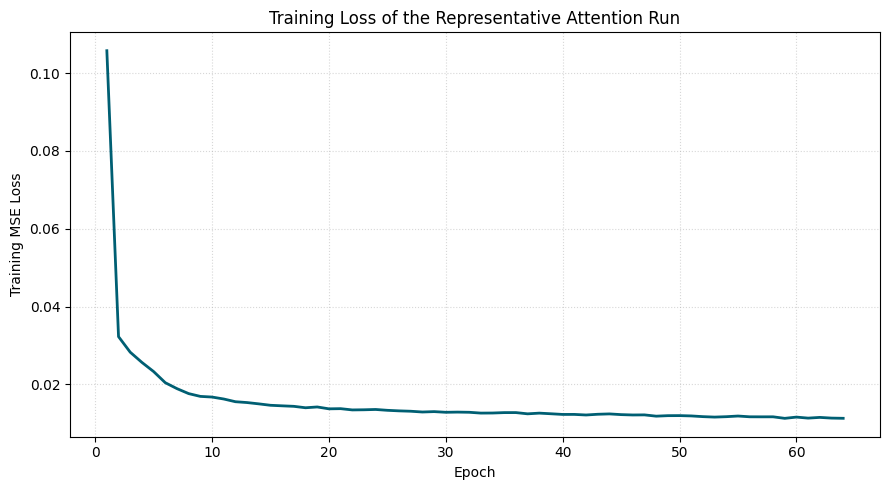

In [11]:
# سلول 11: نمودار روند آموزش اجرای نماینده
plt.figure(figsize=(9, 5))
plt.plot(
    np.arange(1, EPOCHS + 1),
    all_losses[representative_index],
    color='#005F73',
    linewidth=2
)
plt.xlabel('Epoch')
plt.ylabel('Training MSE Loss')
plt.title('Training Loss of the Representative Attention Run')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '08_representative_training_loss.png', dpi=300, bbox_inches='tight')
plt.show()

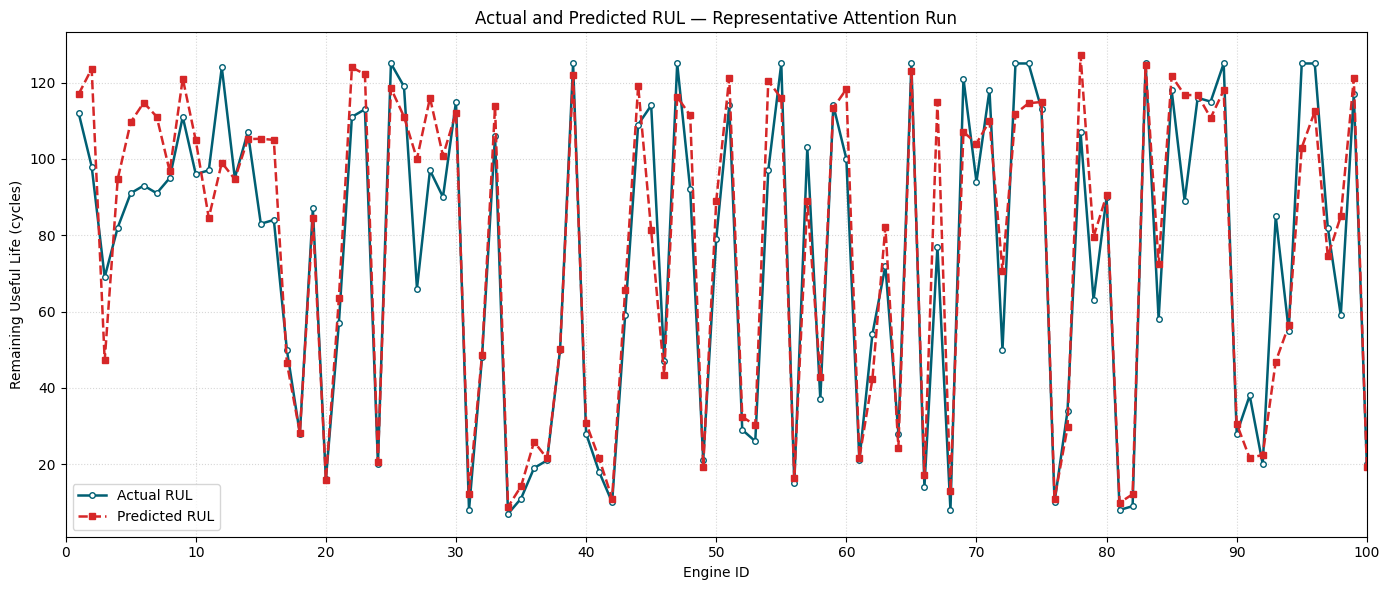

In [12]:
# سلول 12: نمودار RUL واقعی و پیش‌بینی‌شده اجرای نماینده
plt.figure(figsize=(14, 6))
plt.plot(
    engine_ids, testTarget,
    color='#005F73', linewidth=1.8, marker='o', markersize=4,
    markerfacecolor='white', label='Actual RUL'
)
plt.plot(
    engine_ids, representative_prediction,
    color='#D62728', linestyle='--', linewidth=1.8,
    marker='s', markersize=3.8, label='Predicted RUL'
)
plt.xlabel('Engine ID')
plt.ylabel('Remaining Useful Life (cycles)')
plt.title('Actual and Predicted RUL — Representative Attention Run')
plt.xlim(1, len(engine_ids))
plt.xticks(np.arange(0, len(engine_ids) + 1, 10))
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '09_actual_vs_predicted_rul.png', dpi=300, bbox_inches='tight')
plt.show()

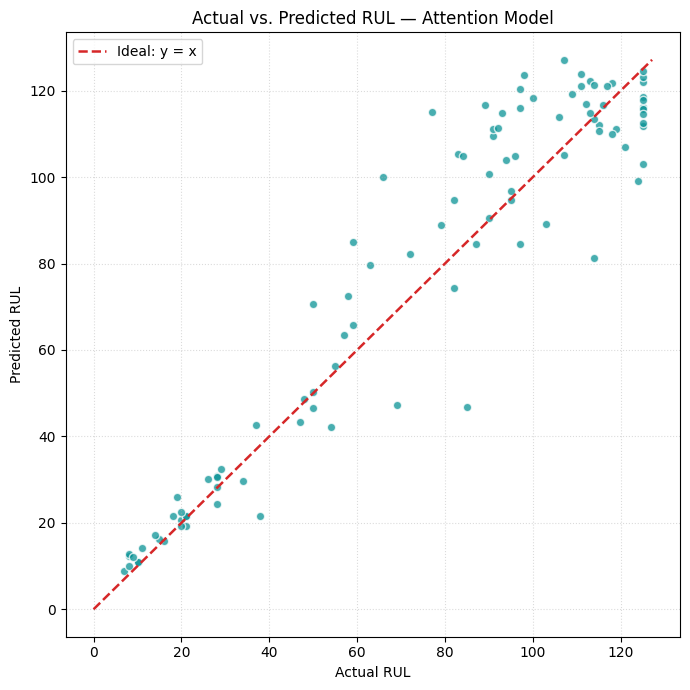

In [13]:
# سلول 13: نمودار پراکنش RUL واقعی و پیش‌بینی‌شده
max_axis = max(float(np.max(testTarget)), float(np.max(representative_prediction)))

plt.figure(figsize=(7, 7))
plt.scatter(testTarget, representative_prediction, color='#0A9396', alpha=0.75, edgecolor='white')
plt.plot([0, max_axis], [0, max_axis], '--', color='#D62728', linewidth=1.8, label='Ideal: y = x')
plt.xlabel('Actual RUL')
plt.ylabel('Predicted RUL')
plt.title('Actual vs. Predicted RUL — Attention Model')
plt.grid(True, linestyle=':', alpha=0.45)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '10_actual_vs_predicted_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

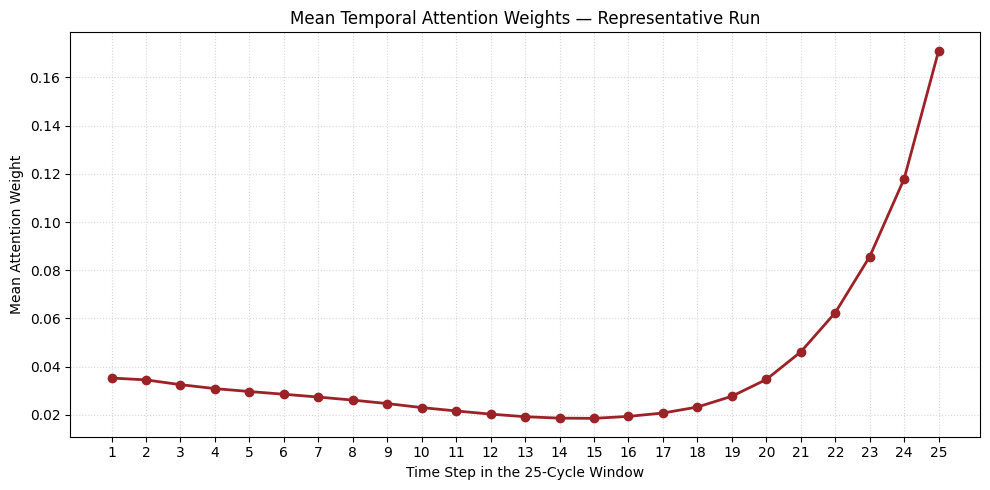

In [14]:
# سلول 14: نمودار میانگین وزن Attention در 25 گام زمانی
plt.figure(figsize=(10, 5))
plt.plot(
    time_steps,
    mean_temporal_attention,
    color='#9B2226', marker='o', linewidth=2
)
plt.xlabel('Time Step in the 25-Cycle Window')
plt.ylabel('Mean Attention Weight')
plt.title('Mean Temporal Attention Weights — Representative Run')
plt.xticks(time_steps)
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '11_mean_temporal_attention.png', dpi=300, bbox_inches='tight')
plt.show()

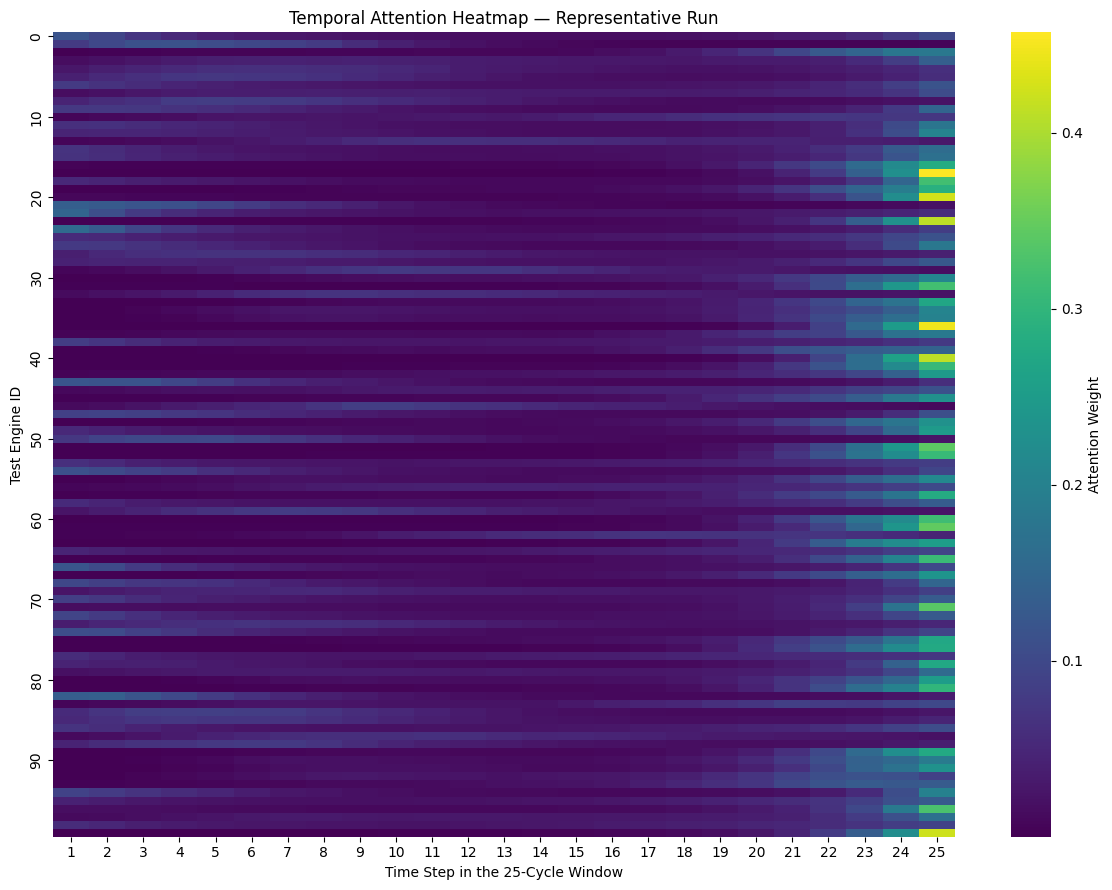

In [15]:
# سلول 15: نقشه حرارتی وزن‌های Attention برای 100 موتور آزمون
plt.figure(figsize=(12, 9))
sns.heatmap(
    representative_attention,
    cmap='viridis',
    cbar_kws={'label': 'Attention Weight'},
    xticklabels=time_steps,
    yticklabels=10
)
plt.xlabel('Time Step in the 25-Cycle Window')
plt.ylabel('Test Engine ID')
plt.title('Temporal Attention Heatmap — Representative Run')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '12_attention_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
# سلول 16: تحلیل خطا در ناحیه نزدیک خرابی (RUL < 30)
critical_mask = testTarget < 30

critical_df = pd.DataFrame([{
    'number_of_critical_engines': int(np.sum(critical_mask)),
    'critical_rmse': float(np.sqrt(mean_squared_error(
        testTarget[critical_mask], representative_prediction[critical_mask]
    ))),
    'critical_mae': float(mean_absolute_error(
        testTarget[critical_mask], representative_prediction[critical_mask]
    )),
    'mean_error_predicted_minus_actual': float(np.mean(
        representative_prediction[critical_mask] - testTarget[critical_mask]
    )),
    'number_of_overestimations': int(np.sum(
        representative_prediction[critical_mask] > testTarget[critical_mask]
    )),
    'number_of_underestimations': int(np.sum(
        representative_prediction[critical_mask] < testTarget[critical_mask]
    ))
}])

critical_df.to_csv(OUTPUT_DIR / '13_critical_zone_rul_below_30.csv', index=False)
display(critical_df)

,number_of_critical_engines,critical_rmse,critical_mae,mean_error_predicted_minus_actual,number_of_overestimations,number_of_underestimations
0,25,2.89726,2.388961,1.887992,21,4


In [17]:
# سلول 17: ثبت تنظیمات و ساخت فایل ZIP خروجی
configuration_df = pd.DataFrame([{
    'run_mode': RUN_MODE,
    'number_of_runs': len(SEEDS),
    'seeds': ','.join(map(str, SEEDS)),
    'max_rul': MAX_RUL,
    'window_size': WINDOW_SIZE,
    'input_sensors': INPUT_DIMS,
    'cnn_filters': CNN_FILTERS,
    'kernel_size': KERNEL_SIZE,
    'bilstm_units_each_direction': BILSTM_UNITS,
    'bilstm_merge_mode': 'concat',
    'attention_type': 'temporal additive attention',
    'attention_units': ATTENTION_UNITS,
    'dropout': DROPOUT_RATE,
    'optimizer': 'Adam',
    'learning_rate': LEARNING_RATE,
    'loss': 'MSE',
    'batch_size': BATCH_SIZE,
    'epochs': EPOCHS,
    'early_stopping': False
}])
configuration_df.to_csv(OUTPUT_DIR / '14_model_configuration.csv', index=False)

zip_path = Path('/content') / f'FD001_CNN_BiLSTM_Attention_{RUN_MODE}_results.zip'
with zipfile.ZipFile(zip_path, 'w', compression=zipfile.ZIP_DEFLATED) as archive:
    for path in sorted(OUTPUT_DIR.iterdir()):
        if path.is_file():
            archive.write(path, arcname=path.name)

print('Output ZIP created:', zip_path)
print('Files included:')
for path in sorted(OUTPUT_DIR.iterdir()):
    print(' -', path.name)

files.download(str(zip_path))

Output ZIP created: /content/FD001_CNN_BiLSTM_Attention_final_results.zip
Files included:
 - 01_attention_run_metrics.csv
 - 02_attention_summary.csv
 - 03_attention_predictions.csv
 - 04_all_run_predictions.csv
 - 05_representative_attention_weights.csv
 - 06_mean_temporal_attention.csv
 - 07_training_loss_histories.csv
 - 08_representative_training_loss.png
 - 09_actual_vs_predicted_rul.png
 - 10_actual_vs_predicted_scatter.png
 - 11_mean_temporal_attention.png
 - 12_attention_heatmap.png
 - 13_critical_zone_rul_below_30.csv
 - 14_model_configuration.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## کنترل نهایی قبل از استفاده در فصل سوم

- اگر `RUN_MODE='pilot'` بوده است، نتایج فقط برای کنترل کد هستند.
- برای نتیجه نهایی، Runtime را Restart کنید، مقدار `RUN_MODE='final'` را تنظیم و همه سلول‌ها را از ابتدا اجرا کنید.
- فایل ZIP حالت نهایی باید شامل نتایج ۱۰ اجرا باشد.
- تعداد اجرای مدل پایه و Attention در مقایسه فصل سوم باید هر دو ۱۰ باشد.
- مقایسه اصلی با میانگین و انحراف معیار RMSE و Score انجام می‌شود، نه فقط بهترین اجرا.
- نمودارهای پیش‌بینی و Attention از اجرای نماینده‌ای رسم می‌شوند که RMSE آن به میانگین ۱۰ اجرا نزدیک‌تر است.